# **Day 57: Semi-Supervised and Active Learning**
*Module 9 - Probabilistic ML, Time Series and Semi-Supervised Learning*

Labels are expensive (field visits, expert annotation, lab analysis); unlabelled data are cheap (a single satellite scene has millions of pixels). Two families of methods make the most of a small labelling budget:
- **Semi-supervised learning**: use the **unlabelled** data during training.
- **Active learning**: let the model choose **which** samples a human should label next.

> Labels are expensive while unlabelled data is cheap. Semi-supervised learning uses both. Active learning asks a human to label only the most informative samples.
>
> *Example:* Instead of labelling 5,000 random pixels, active learning asks us to label the 200 the model is most unsure about, often reaching the same accuracy.

In [1]:
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)   # harmless numerical warnings (see text)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_classification, load_digits
from sklearn.semi_supervised import SelfTrainingClassifier, LabelPropagation, LabelSpreading
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
rng = np.random.default_rng(57)

## **1. When Can Unlabelled Data Help?**
Unlabelled data reveal the **shape** of the data distribution. They help if the decision boundary should pass through **low-density regions** (cluster assumption) or follow a **low-dimensional manifold**. If classes overlap heavily, they can hurt.

## **2. Graph-Based Label Propagation**
Build a similarity graph over all points (labelled + unlabelled); labels flow along edges to nearby points.

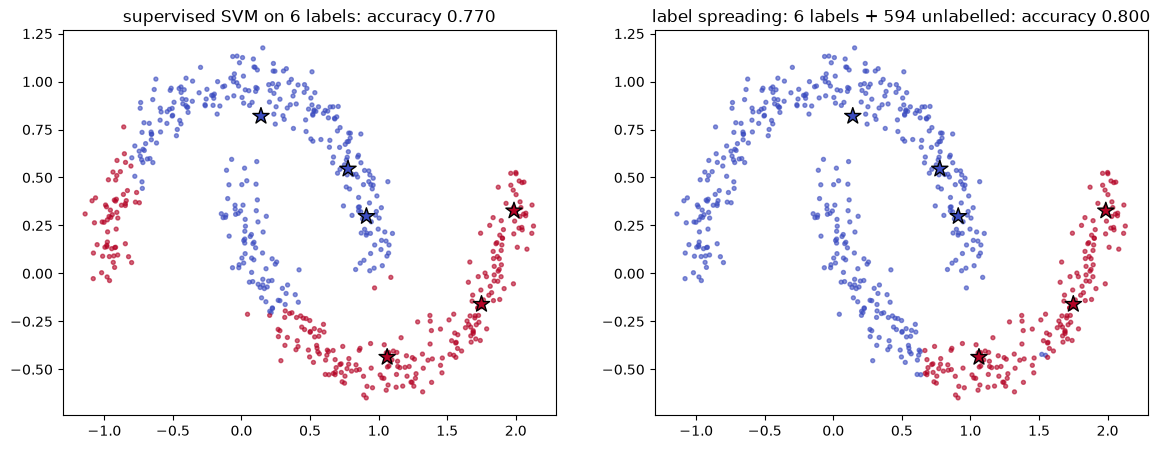

In [2]:
X, y = make_moons(600, noise=0.08, random_state=0)
y_semi = np.full(len(y), -1)                                     # -1 = unlabelled (sklearn convention)
labelled = np.r_[rng.choice(np.flatnonzero(y == 0), 3, replace=False), rng.choice(np.flatnonzero(y == 1), 3, replace=False)]
y_semi[labelled] = y[labelled]
sup = SVC(gamma=2).fit(X[labelled], y[labelled])
ls = LabelSpreading(kernel="knn", n_neighbors=10, alpha=0.2).fit(X, y_semi)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, pred) in zip(axes, [("supervised SVM on 6 labels", sup.predict(X)), ("label spreading: 6 labels + 594 unlabelled", ls.transduction_)]):
    ax.scatter(*X.T, c=pred, cmap="coolwarm", s=8, alpha=0.6); ax.scatter(*X[labelled].T, c=y[labelled], cmap="coolwarm", s=150, marker="*", edgecolor="k")
    ax.set_title(f"{name}: accuracy {np.mean(pred == y):.3f}")
plt.show()

## **3. Self-Training (Pseudo-Labelling)**
1. Train on the labelled data.
2. Predict the unlabelled data; add the **most confident** predictions as pseudo-labels.
3. Retrain; repeat.
Simple and works with any probabilistic classifier, but wrong confident pseudo-labels reinforce themselves (**confirmation bias**).

In [3]:
Xd, yd = load_digits(return_X_y=True)
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, test_size=0.4, stratify=yd, random_state=0)
sc = StandardScaler().fit(Xd_tr); Xd_tr, Xd_te = sc.transform(Xd_tr), sc.transform(Xd_te)
rows = []
for n_lab in [20, 50, 100, 200]:
    lab_idx = np.concatenate([rng.choice(np.flatnonzero(yd_tr == c), n_lab // 10, replace=False) for c in range(10)])
    ys = np.full(len(yd_tr), -1); ys[lab_idx] = yd_tr[lab_idx]
    base = LogisticRegression(max_iter=3000, C=0.5)
    sup_acc = base.fit(Xd_tr[lab_idx], yd_tr[lab_idx]).score(Xd_te, yd_te)
    st_acc = SelfTrainingClassifier(LogisticRegression(max_iter=3000, C=0.5), threshold=0.9).fit(Xd_tr, ys).score(Xd_te, yd_te)
    lsp_acc = (LabelSpreading(kernel="knn", n_neighbors=7, alpha=0.2).fit(Xd_tr, ys).predict(Xd_te) == yd_te).mean()
    rows.append({"labelled": n_lab, "supervised only": sup_acc, "self-training": st_acc, "label spreading": lsp_acc})
pd.DataFrame(rows).set_index("labelled").round(3)

,supervised only,self-training,label spreading
labelled,,,
20,0.709,0.622,0.789
50,0.850,0.879,0.919
100,0.904,0.918,0.946
200,0.919,0.935,0.947


Label spreading gives large gains with very few labels on the digits (whose classes form well-separated clusters); the advantage shrinks as labels increase. Self-training can **hurt** when the initial model is poor (20 labels): it adds many confident but wrong pseudo-labels, the confirmation bias studied in Part 2.

## **4. Active Learning**
Start with a few labels; repeatedly ask an oracle (the human expert) to label the samples the model is **least sure about**.

| Query strategy | Score (pick the largest) |
|---|---|
| Least confidence | $1 - \max_k p_k$ |
| Margin | $-(p_{(1)} - p_{(2)})$ (small gap between the top two classes) |
| Entropy | $-\sum_k p_k\log p_k$ |
| Query-by-committee | disagreement among an ensemble (vote entropy) |
| Random | baseline |

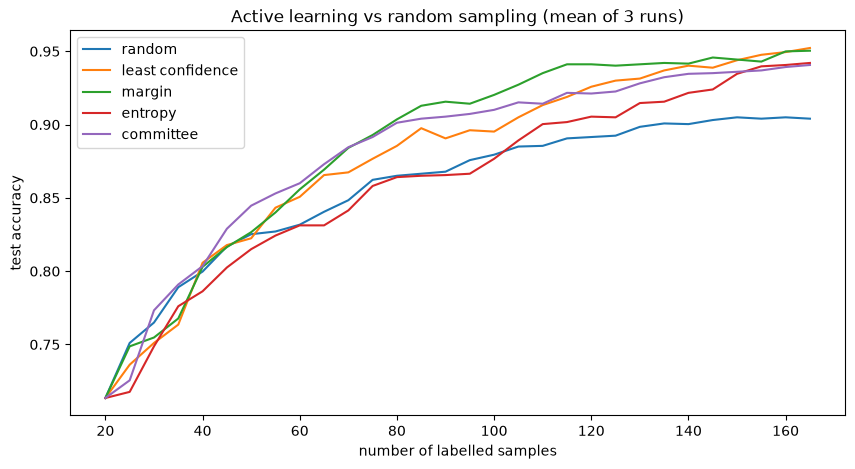

In [4]:
def active_learning(X_pool, y_pool, X_test, y_test, strategy, n_init=20, n_queries=150, batch=5, seed=0):
    r = np.random.default_rng(seed)
    labelled = list(np.concatenate([r.choice(np.flatnonzero(y_pool == c), max(1, n_init // len(np.unique(y_pool))), replace=False) for c in np.unique(y_pool)]))
    curve = []
    while len(labelled) < n_init + n_queries:
        m = LogisticRegression(max_iter=3000, C=0.5).fit(X_pool[labelled], y_pool[labelled])
        curve.append((len(labelled), m.score(X_test, y_test)))
        pool = np.setdiff1d(np.arange(len(X_pool)), labelled)
        if strategy == "random":
            pick = r.choice(pool, batch, replace=False)
        elif strategy == "committee":
            committee = [RandomForestClassifier(30, max_depth=8, random_state=k).fit(X_pool[labelled][bi], y_pool[labelled][bi])
                         for k, bi in enumerate([r.integers(0, len(labelled), len(labelled)) for _ in range(5)])]
            votes = np.array([c.predict(X_pool[pool]) for c in committee])
            vote_entropy = np.array([-(np.bincount(v, minlength=10) / 5 * np.log(np.bincount(v, minlength=10) / 5 + 1e-12)).sum() for v in votes.T])
            pick = pool[np.argsort(vote_entropy)[-batch:]]
        else:
            P = m.predict_proba(X_pool[pool]); Ps = np.sort(P, 1)
            score = {"least confidence": 1 - Ps[:, -1], "margin": -(Ps[:, -1] - Ps[:, -2]), "entropy": -(P * np.log(P + 1e-12)).sum(1)}[strategy]
            pick = pool[np.argsort(score)[-batch:]]
        labelled += list(pick)
    return np.array(curve)

plt.figure(figsize=(10, 5))
for strat in ["random", "least confidence", "margin", "entropy", "committee"]:
    curves = [active_learning(Xd_tr, yd_tr, Xd_te, yd_te, strat, seed=s) for s in range(3)]
    c = np.mean(curves, axis=0); plt.plot(c[:, 0], c[:, 1], label=strat)
plt.xlabel("number of labelled samples"); plt.ylabel("test accuracy"); plt.legend(); plt.title("Active learning vs random sampling (mean of 3 runs)"); plt.show()

Uncertainty-based strategies reach a given accuracy with **fewer labels** than random sampling. In remote sensing this means fewer field visits or photo-interpretation hours (Tuia et al., 2011).

# **Part 2: Going Deeper - Pitfalls**

### Confirmation bias in self-training
When classes **overlap**, confident-but-wrong pseudo-labels accumulate. A low threshold makes it worse.

In [5]:
Xo, yo = make_classification(3000, 10, n_informative=4, class_sep=0.5, flip_y=0.1, random_state=1)
Xo_tr, Xo_te, yo_tr, yo_te = train_test_split(Xo, yo, test_size=0.4, random_state=0)
lab = rng.choice(len(yo_tr), 40, replace=False); yso = np.full(len(yo_tr), -1); yso[lab] = yo_tr[lab]
print(f"supervised (40 labels): {LogisticRegression().fit(Xo_tr[lab], yo_tr[lab]).score(Xo_te, yo_te):.3f}")
for thr in [0.99, 0.9, 0.7, 0.55]:
    st = SelfTrainingClassifier(LogisticRegression(), threshold=thr).fit(Xo_tr, yso)
    added = st.labeled_iter_ > 0
    print(f"self-training threshold {thr}: accuracy {st.score(Xo_te, yo_te):.3f} | pseudo-labels added {added.sum()} | wrong among them {np.mean(st.transduction_[added] != yo_tr[added]):.2f}")

supervised (40 labels): 0.603
self-training threshold 0.99: accuracy 0.603 | pseudo-labels added 7 | wrong among them 0.00
self-training threshold 0.9: accuracy 0.576 | pseudo-labels added 1370 | wrong among them 0.41
self-training threshold 0.7: accuracy 0.591 | pseudo-labels added 1667 | wrong among them 0.41
self-training threshold 0.55: accuracy 0.595 | pseudo-labels added 1748 | wrong among them 0.41


### Batch-mode diversity
Picking the top-k uncertain samples often selects near-duplicates (all from the same ambiguous region). Combine **uncertainty** with **diversity**: e.g. take the top 10k uncertain candidates and choose k cluster centres among them (k-means), or penalise similarity to already selected samples.

In [6]:
from sklearn.cluster import KMeans
def diverse_batch(m, X_pool, pool, batch=5, n_cand=50):
    P = np.sort(m.predict_proba(X_pool[pool]), 1); margin = P[:, -1] - P[:, -2]
    cand = pool[np.argsort(margin)[:n_cand]]
    km = KMeans(batch, n_init=5, random_state=0).fit(X_pool[cand])
    return np.array([cand[np.argmin(((X_pool[cand] - c) ** 2).sum(1))] for c in km.cluster_centers_])
m0 = LogisticRegression(max_iter=3000).fit(Xd_tr[:30], yd_tr[:30]); pool0 = np.arange(30, len(Xd_tr))
top = pool0[np.argsort(np.diff(np.sort(m0.predict_proba(Xd_tr[pool0]), 1)[:, -2:], axis=1).ravel())[:5]]
div = diverse_batch(m0, Xd_tr, pool0)
print("labels of a top-5 margin batch:", yd_tr[top], "| labels of a diverse batch:", yd_tr[div])

labels of a top-5 margin batch: [4 9 9 9 3] | labels of a diverse batch: [7 8 9 4 4]


### Practical recipe for a labelling campaign
1. Start with a small **stratified random** sample (cold start, and an unbiased validation set).
2. Iterate: train -> query uncertain **and** diverse samples -> label -> retrain.
3. Keep a separate random **test sample**: actively selected samples are biased and cannot estimate map accuracy (Day 88).
4. Combine with semi-supervised learning and with pretrained features / foundation models (Day 70, 76).

## **Practice Problems**
1. Vary `n_neighbors` (3, 7, 15, 30) in label spreading on the digits with 20 labels. What happens with too few or too many neighbours?
2. Run the active-learning comparison with `batch=1` and `batch=20`. Does batch size change the gain over random sampling?
3. Combine active learning and self-training: after each query round, add pseudo-labels with confidence > 0.95 for training only.
4. *(Advanced)* Show why actively selected samples give a **biased** accuracy estimate: compare accuracy on the queried samples with accuracy on the random test set.

In [7]:
# Solution 1
lab20 = np.concatenate([rng.choice(np.flatnonzero(yd_tr == c), 2, replace=False) for c in range(10)]); ys20 = np.full(len(yd_tr), -1); ys20[lab20] = yd_tr[lab20]
for k in [3, 7, 15, 30]:
    print(f"n_neighbors={k:>2}: accuracy {(LabelSpreading(kernel='knn', n_neighbors=k, alpha=0.2).fit(Xd_tr, ys20).predict(Xd_te) == yd_te).mean():.3f}")
# Solution 2
for b in [1, 20]:
    ra = active_learning(Xd_tr, yd_tr, Xd_te, yd_te, "random", batch=b, n_queries=100)[-1, 1]
    ma = active_learning(Xd_tr, yd_tr, Xd_te, yd_te, "margin", batch=b, n_queries=100)[-1, 1]
    print(f"batch {b:>2}: random {ra:.3f} | margin {ma:.3f}")
# Solution 3: active learning + pseudo-labels (pseudo-labels used for training only, never for evaluation)
r3 = np.random.default_rng(3); lab3 = list(np.concatenate([r3.choice(np.flatnonzero(yd_tr == c), 2, replace=False) for c in range(10)]))
for _ in range(16):
    pool3 = np.setdiff1d(np.arange(len(Xd_tr)), lab3)
    m3 = LogisticRegression(max_iter=3000, C=0.5).fit(Xd_tr[lab3], yd_tr[lab3]); P3 = m3.predict_proba(Xd_tr[pool3])
    conf = pool3[P3.max(1) > 0.95]
    m3 = LogisticRegression(max_iter=3000, C=0.5).fit(np.r_[Xd_tr[lab3], Xd_tr[conf]], np.r_[yd_tr[lab3], m3.predict(Xd_tr[conf])])
    Ps3 = np.sort(m3.predict_proba(Xd_tr[pool3]), 1); lab3 += list(pool3[np.argsort(Ps3[:, -1] - Ps3[:, -2])[:5]])
print(f"AL + pseudo-labels with {len(lab3)} true labels: test accuracy {m3.score(Xd_te, yd_te):.3f}")
# Solution 4
r_ = np.random.default_rng(1); labelled = list(r_.choice(len(Xd_tr), 20, replace=False)); queried = []
for _ in range(20):
    m_ = LogisticRegression(max_iter=3000).fit(Xd_tr[labelled], yd_tr[labelled]); pool_ = np.setdiff1d(np.arange(len(Xd_tr)), labelled)
    Ps_ = np.sort(m_.predict_proba(Xd_tr[pool_]), 1); pick = pool_[np.argsort(Ps_[:, -1] - Ps_[:, -2])[:5]]
    queried += list(pick); labelled += list(pick)
m_final = LogisticRegression(max_iter=3000).fit(Xd_tr[labelled[:-25]], yd_tr[labelled[:-25]])     # model BEFORE the last 5 query rounds
print(f"accuracy on the next 25 queried (hard) samples {m_final.score(Xd_tr[queried[-25:]], yd_tr[queried[-25:]]):.3f} vs random test set {m_final.score(Xd_te, yd_te):.3f}")
print("Actively selected samples are the hardest ones, so accuracy measured on them is strongly pessimistic (and on easy, confidently-predicted samples it would be optimistic).")

n_neighbors= 3: accuracy 0.357
n_neighbors= 7: accuracy 0.787


n_neighbors=15: accuracy 0.755
n_neighbors=30: accuracy 0.762


batch  1: random 0.921 | margin 0.943
batch 20: random 0.915 | margin 0.925


AL + pseudo-labels with 100 true labels: test accuracy 0.918
accuracy on the next 25 queried (hard) samples 0.520 vs random test set 0.919
Actively selected samples are the hardest ones, so accuracy measured on them is strongly pessimistic (and on easy, confidently-predicted samples it would be optimistic).


## **Key References**
- Zhu, X., & Goldberg, A. B. (2009). *Introduction to Semi-Supervised Learning*. Morgan & Claypool.
- Zhou, D., Bousquet, O., Lal, T. N., Weston, J., & Scholkopf, B. (2004). Learning with local and global consistency. *NeurIPS 16* (label spreading).
- Yarowsky, D. (1995). Unsupervised word sense disambiguation rivaling supervised methods. *ACL 1995* (self-training).
- Settles, B. (2009). Active learning literature survey. Computer Sciences Technical Report 1648, University of Wisconsin-Madison.
- Tuia, D., Volpi, M., Copa, L., Kanevski, M., & Munoz-Mari, J. (2011). A survey of active learning algorithms for supervised remote sensing image classification. *IEEE Journal of Selected Topics in Signal Processing*, 5(3), 606-617.
- van Engelen, J. E., & Hoos, H. H. (2020). A survey on semi-supervised learning. *Machine Learning*, 109(2), 373-440.